# Fraud Detection using Machine Learning

Goal:
Detect fraudulent credit card transactions while handling severe class imbalance using SMOTE.

Dataset:
Kaggle Credit Card Fraud Detection Dataset

Models:
• Logistic Regression
• Random Forest

Evaluation Metrics:
• Precision
• Recall
• F1 Score
• ROC AUC

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Observation

No missing values were found in the dataset.

The dataset is already cleaned.

In [8]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
fraud = df["Class"].value_counts()[1]
normal = df["Class"].value_counts()[0]

print(fraud)
print(normal)

492
284315


In [10]:
fraud_percentage = df["Class"].mean()*100

print(f"Fraud Transactions: {fraud_percentage:.4f}%")

Fraud Transactions: 0.1727%


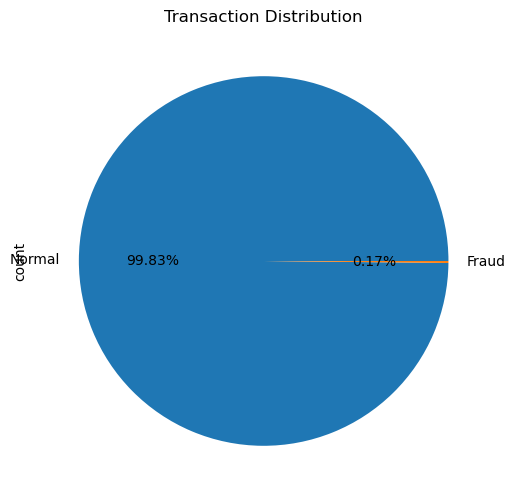

In [11]:
plt.figure(figsize=(6,6))

df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    labels=["Normal","Fraud"]
)

plt.title("Transaction Distribution")
plt.show()

Observation

Only around 0.17% of all transactions are fraudulent.

This is an extremely imbalanced dataset.

A model predicting every transaction as "Normal"
would achieve nearly 99.8% accuracy while detecting
zero fraud cases.

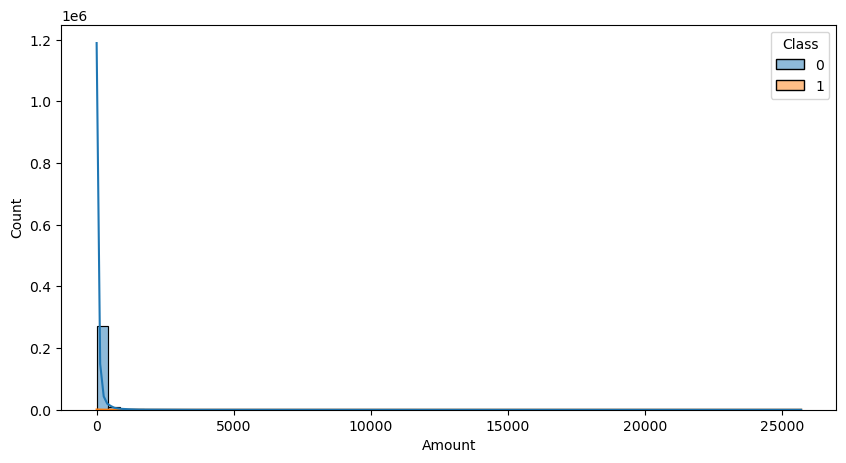

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=60,
    kde=True
)

plt.show()

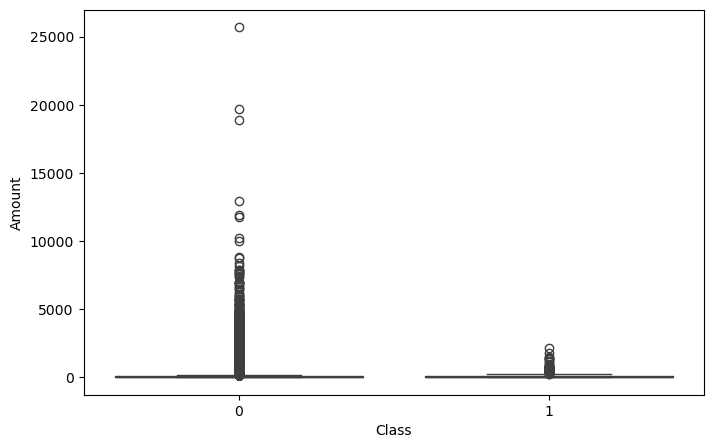

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.show()

Observation

Fraudulent transactions are distributed across various
transaction amounts.

Although many frauds involve smaller amounts,
there are also high-value fraudulent transactions.

Transaction amount alone cannot distinguish fraud.

In [14]:
df["Hour"] = df["Time"] // 3600

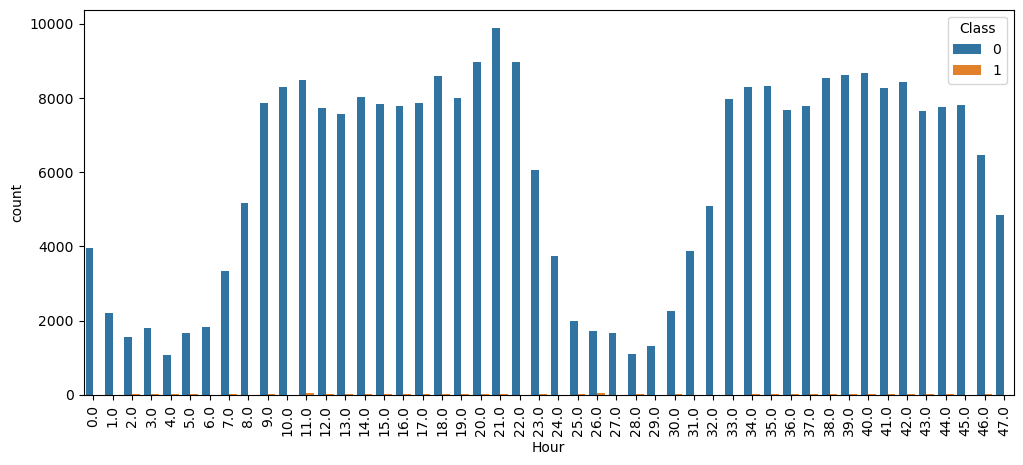

In [15]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="Hour",
    hue="Class",
    data=df
)

plt.xticks(rotation=90)
plt.show()

Observation

Fraud occurs throughout the day.

Certain hours exhibit relatively higher fraud activity,
suggesting temporal patterns that may help prediction.

In [16]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [17]:
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Why Stratification?

Without stratification,
the test set may contain very few or even zero fraud cases,
making evaluation unreliable.

Stratification preserves the fraud ratio in both sets.

In [19]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [20]:
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

Observation

SMOTE synthetically generates minority-class samples
instead of duplicating existing ones.

This helps the model learn fraud patterns more effectively.

In [21]:
lr = LogisticRegression()

lr.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [26]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [28]:
def evaluate_model(name, y_true, pred, prob):

    print("="*40)
    print(name)
    print("="*40)

    print("Accuracy :", accuracy_score(y_true,pred))

    print("Precision:", precision_score(y_true,pred))

    print("Recall   :", recall_score(y_true,pred))

    print("F1 Score :", f1_score(y_true,pred))

    print("ROC AUC  :", roc_auc_score(y_true,prob))

    print()

    print(classification_report(y_true,pred))

In [29]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

Logistic Regression
Accuracy : 0.9825146588954039
Precision: 0.08271375464684015
Recall   : 0.9081632653061225
F1 Score : 0.151618398637138
ROC AUC  : 0.9754419423931644

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.91      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962

Random Forest
Accuracy : 0.999403110845827
Precision: 0.8333333333333334
Recall   : 0.8163265306122449
F1 Score : 0.8247422680412371
ROC AUC  : 0.9644096225293719

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



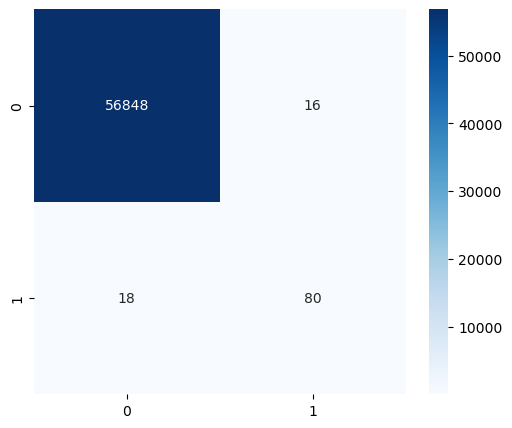

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test,rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

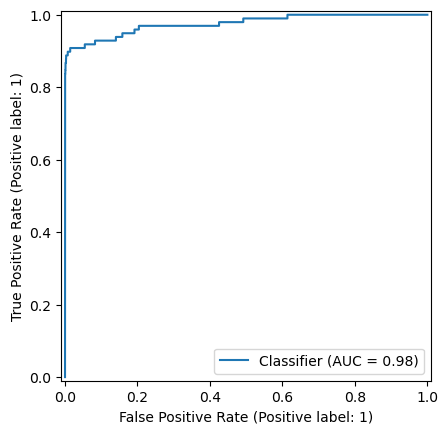

In [31]:
RocCurveDisplay.from_predictions(
    y_test,
    lr_prob
)

plt.show()

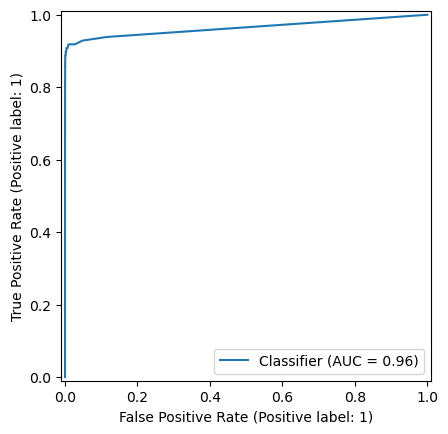

In [32]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.show()

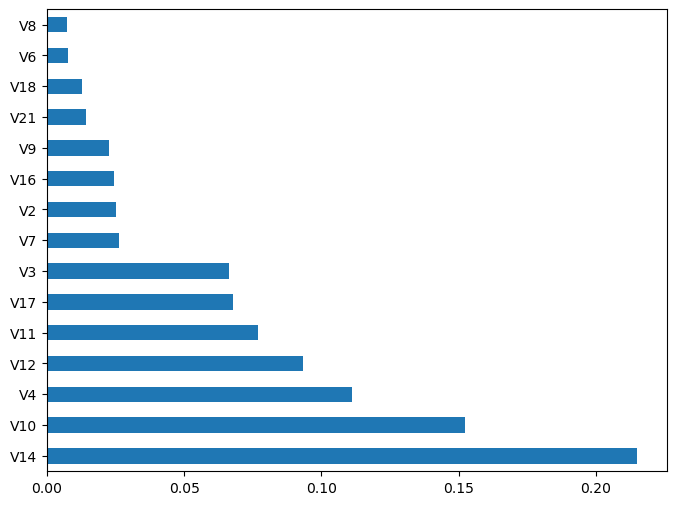

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.show()

Observation

The Random Forest model identifies the most influential
features contributing to fraud detection.

These features can assist investigators in understanding
suspicious transaction patterns.

Why Accuracy is Misleading

Suppose we have:

100,000 transactions

Only 100 are fraud.

If the model predicts every transaction as Normal:

Accuracy = 99.9%

Frauds detected = 0

Business Value = Zero

Therefore,

Accuracy is not suitable for highly imbalanced datasets.

Instead we use

• Precision
• Recall
• F1 Score
• ROC AUC

Recall measures how many fraudulent transactions are detected.

High Recall means fewer frauds are missed.

Precision measures how many detected frauds are actually fraud.

For banking systems,
missing a fraud (False Negative)
is usually more expensive than investigating
a legitimate transaction (False Positive).

Therefore,

Recall is generally considered the most important metric
for fraud detection.

How would this model process one million transactions per hour?

Possible improvements:

• Deploy the model as a REST API using FastAPI.

• Stream transactions through Kafka.

• Perform inference in batches.

• Use Spark for distributed processing.

• Continuously retrain using newly labeled fraud cases.

• Monitor concept drift because fraud patterns evolve over time.

• Deploy on cloud infrastructure with autoscaling.

Project Summary

✔ Analyzed severe class imbalance

✔ Performed exploratory data analysis

✔ Applied SMOTE

✔ Trained Logistic Regression

✔ Trained Random Forest

✔ Compared models using Recall,
Precision,
F1 Score,
ROC AUC

✔ Interpreted feature importance

✔ Discussed production scalability

The Random Forest model achieved stronger fraud detection performance while maintaining high Recall, making it more suitable for identifying fraudulent transactions in this benchmark dataset.